In [2]:
## We are doing a simple image classification task using the MNIST dataset. The MNIST dataset consists of 28x28 pixel grayscale images of handwritten digits (0-9). The goal is to classify these images into their respective digit classes.

# hand written digits classification


import torch 
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt

In [5]:
# get the MNIST dataset for training

transform = transforms.Compose([
          transforms.ToTensor(), # converstingto tensor and then converting the pixel values to the range [0, 1]
          transforms.Normalize((0.5,), (0.5,)) # normalizing the pixel values to the range [-1, 1]
])
train_dataset = datasets.MNIST(
          root="data",
          train=True,
          transform=transform,
          download=True
)

# get the MNIST dataset for test
test_dataset = datasets.MNIST(
          root="data",
          train=False,
          transform=transform,
          download=True
)


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.14MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 114kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.04MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.02MB/s]


In [6]:
# length of the dataset

len(train_dataset), len(test_dataset)

(60000, 10000)

In [ ]:
# using the DataLoader to load the dataset in batches and shuffle the data for training
train_dataloader = DataLoader(
          dataset=train_dataset,
          batch_size=64,
          shuffle=True
)

test_dataloader = DataLoader(
          dataset=test_dataset,
          batch_size=64,
          shuffle=False
)

In [8]:
train_data_loader_itr = iter(train_dataloader)

train_images, train_labels = next(train_data_loader_itr)

train_images.shape, train_labels.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

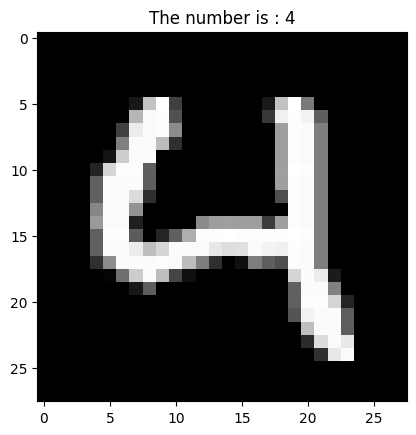

In [ ]:
## Show the image using matplotlib

plt.imshow(train_images[0].squeeze(), cmap='gray')
plt.title(f"The number is : {train_labels[0].item()}")
plt.show()

In [ ]:
28*28 # converst to single array so size is 784 

784

In [13]:
class HandWrittenDigitClassifier(nn.Module):
          def __init__(self):
                  super().__init__()
                  self.network = nn.Sequential(
                          nn.Flatten() ,# convert pixel to one grid array like 28*28 to single array
                          nn.Linear(784, 128), # 784 input layres and 128 hiden layers 
                          nn.ReLU(),    
                          nn.Linear(128, 64),   # 128 input layers and 64 hidden ;ayers 
                          nn.ReLU(),   
                          nn.Linear(64, 10)

                  )

          def forward(self,X):
                  return self.network(X)


In [15]:
model = HandWrittenDigitClassifier()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion  = nn.CrossEntropyLoss()

In [18]:
epochs = 5
for epoch in range(epochs):
          running_loss = 0.0
          for t_images , t_labels in train_dataloader:
                  ## forward
                  outputs = model(t_images)
                  loss = criterion(outputs, t_labels) # calculate the loss
                  running_loss += loss.item()

                  ## Backward 
                  optimizer.zero_grad()
                  loss.backward()
                  ## weights update
                  optimizer.step() # 

          print(f"Epoch [{epoch+1}/{epochs}], Loss : {running_loss / len(train_dataloader):.2f}")



Epoch [1/5], Loss : 0.19
Epoch [2/5], Loss : 0.14
Epoch [3/5], Loss : 0.11
Epoch [4/5], Loss : 0.09
Epoch [5/5], Loss : 0.08


In [21]:
model.eval()

with torch.no_grad():
          for images , labels in test_dataloader:
                  pred = model(images)
                  print(pred[0])

                  print("========================")
                  print(labels[0])

                  break


tensor([ -4.7301,  -2.5782,   0.6408,   0.9192, -10.2579,  -5.0357, -12.8307,
         10.5532,  -0.5729,  -3.0700])
tensor(7)
